
**Concept: Hierarchical Clustering**

Hierarchical clustering is a method of cluster analysis that seeks to build a hierarchy of clusters.  There are two main types:

*   **Agglomerative (bottom-up):** This is the more common type. It starts with each data point as its own cluster and iteratively merges the closest pairs of clusters until only one cluster remains.
*   **Divisive (top-down):** This approach starts with all data points in one cluster and recursively splits it into smaller clusters.

We'll focus on **agglomerative hierarchical clustering** in this explanation.

**Steps Involved (Agglomerative):**

1.  **Initialization:** Each data point is treated as an individual cluster.
2.  **Distance Calculation:** Calculate the distance between each pair of clusters. Common distance metrics include:
    *   Euclidean distance
    *   Manhattan distance
    *   Cosine similarity
3.  **Cluster Merging:** Merge the two closest clusters based on a linkage criterion. Linkage criteria determine the distance between sets of observations as a function of the pairwise distances between observations. Common linkage criteria are:
    *   **Single Linkage:** The distance between two clusters is the shortest distance between any point in one cluster and any point in the other cluster.
    *   **Complete Linkage:** The distance between two clusters is the longest distance between any point in one cluster and any point in the other cluster.
    *   **Average Linkage:** The distance between two clusters is the average distance between all pairs of points from the two clusters.
    *   **Ward Linkage:** Minimizes the total within-cluster variance. At each step, the pair of clusters with the smallest increase in total within-cluster variance after merging is chosen.
4.  **Iteration:** Repeat steps 2 and 3 until all data points are merged into a single cluster.
5.  **Dendrogram:** The result is often visualized using a dendrogram, a tree-like diagram that shows the hierarchy of cluster merges and the distances at which they occurred.

**Code and Explanation**

**1. Import Libraries**

In [1]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

**2. Generate Sample Data**

We'll use `make_blobs` from `scikit-learn` to create some synthetic data for demonstration.

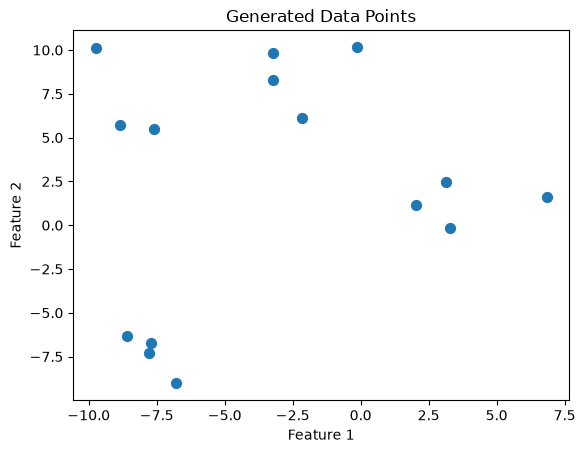

In [2]:
X, y = make_blobs(n_samples=15, centers=4, random_state=42, cluster_std=1.5)

# Visualize the generated data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Generated Data Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**3. Calculate the Linkage Matrix**

We'll use the `linkage` function from `scipy.cluster.hierarchy` to compute the linkage matrix, which encodes the hierarchical clustering.

In [3]:
# Calculate the linkage matrix using 'ward' linkage (you can try other methods)
Z = linkage(X, method="ward")

**4. Plot the Dendrogram**

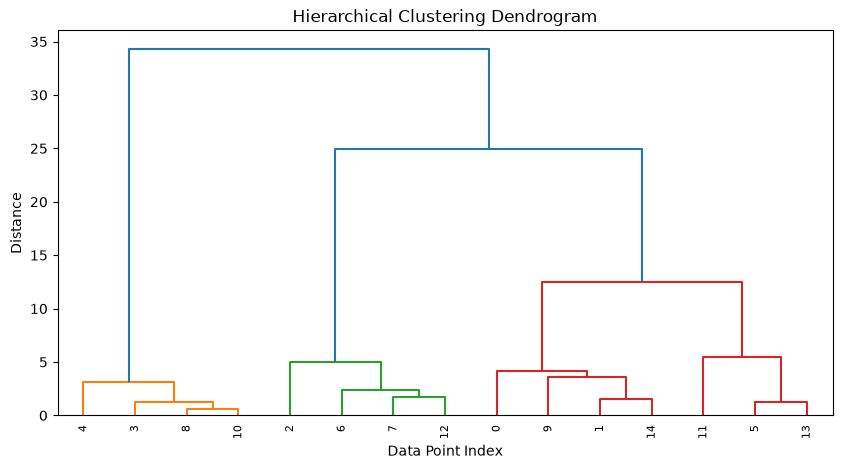

In [4]:
# Plot the dendrogram
plt.figure(figsize=(10, 5))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Point Index")
plt.ylabel("Distance")
dendrogram(Z, leaf_rotation=90.0, leaf_font_size=8.0)
plt.show()

**Explanation of the Dendrogram:**

*   **X-axis:** Represents the data points (initially as individual clusters).
*   **Y-axis:** Represents the distance at which clusters are merged.
*   **Branches:** Show how clusters are merged. The height of a branch indicates the distance between the merged clusters.

**5. Perform Agglomerative Clustering**

Now, we'll use `AgglomerativeClustering` from `scikit-learn` to actually perform the clustering and assign cluster labels to our data points.

In [5]:
# Perform agglomerative clustering with a specified number of clusters (e.g., 3)
cluster = AgglomerativeClustering(
    n_clusters=4, linkage="ward"
)  # Remove affinity argument
labels = cluster.fit_predict(X)

**6. Visualize the Clusters**

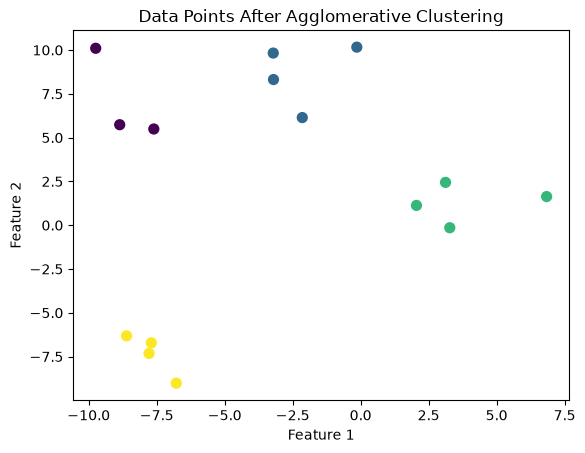

In [6]:
# Visualize the clustered data
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap="viridis")
plt.title("Data Points After Agglomerative Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Explanation of the Cluster Visualization:**

*   Each color represents a different cluster.
*   The points with the same color belong to the same cluster.

**Determining the Number of Clusters**

You can use the dendrogram to help you decide on the number of clusters. Look for large vertical distances where merges happen. These distances suggest a natural separation between clusters.

**Example using other linkage method**

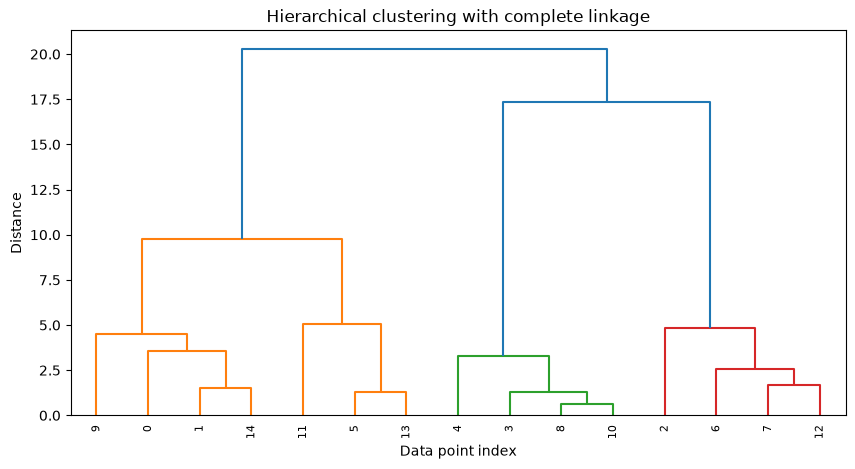

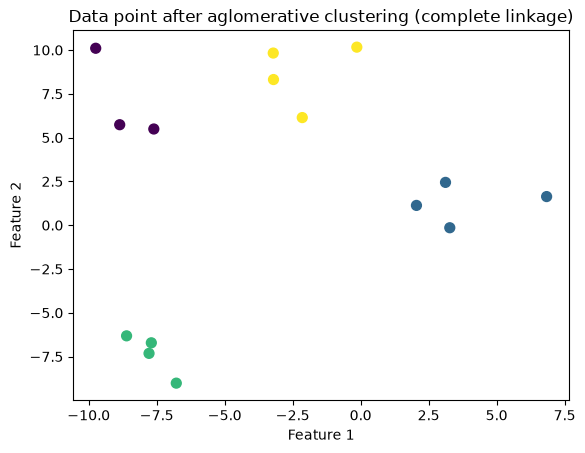

In [7]:
# Calculate linkage matrix using "complete" linkage
Z_complete = linkage(X, method="complete")

# Plot the dendrogram for "complete" linkage
plt.figure(figsize=(10, 5))
plt.title("Hierarchical clustering with complete linkage")
plt.xlabel("Data point index")
plt.ylabel("Distance")
dendrogram(Z_complete, leaf_rotation=90.0, leaf_font_size=8.0)
plt.show()

# Perform aglomerative clustering with "complete" linkage
cluster_complete = AgglomerativeClustering(
    n_clusters=4, linkage="complete"
)  # Remove affinity='euclidean'
labels_complete = cluster_complete.fit_predict(X)

# Visualize the clusters for "complete" linkage
plt.scatter(X[:, 0], X[:, 1], c=labels_complete, s=50, cmap="viridis")
plt.title("Data point after aglomerative clustering (complete linkage)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In this example, we used the `complete` linkage method instead of `ward`. The dendrogram and cluster visualization demonstrate the difference in clustering results when using different linkage methods.

**Conclusion**

This step-by-step guide, along with the code and visualizations, should provide a solid foundation for your students to understand hierarchical clustering. Encourage them to experiment with different linkage methods, distance metrics, and datasets to get a better feel for how the algorithm works in practice. Remember to relate these concepts back to real-world examples to make them more relatable. Please let me know if you have any other questions.